##### Copyright 2024 Multimodal Universe Collaboration

Licensed under MIT License (the "License")

**Authors**:
- [@EiffL](https://github.com/EiffL) (Francois Lanusse)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datasets import load_dataset

/Users/green/Downloads/Multimodal_Universe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Getting Started with the Multimodal Universe Dataset!

<p align="center">
<img src="https://raw.githubusercontent.com/MultimodalUniverse/MultimodalUniverse/main/assets/multimodal_universe.png" alt="drawing" width="400"/>
<p>

### Overview

In this notebook we demonstrate how to access the data from the Multimodal Universe dataset, provide explanations about how to understand and work with each modality, and provide examples of multimodal cross-matching.

### Learning Objectives

In this notebook, we will learn how to:
 - Access datasets of different modalities
 - Cross-match different datasets


### Installs and Imports

To get started with the dataset, we only need to install Hugging Face Datasets:

In [2]:
# Installing Hugging Face datasets
%pip install datasets --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


And that's it, we are set 😀 Let's just import a few things and then we can get started:

In [3]:
from datasets import load_dataset

## Image Samples


In [4]:
dset_ls = load_dataset("MultimodalUniverse/legacysurvey",
                       streaming=True,
                       split='train')
dset_ls = dset_ls.with_format("numpy")
dset_iterator = iter(dset_ls)

In [ ]:
example = next(dset_iterator)

In [ ]:
# Let's inspect what is contained in an example
example.keys()

dict_keys(['image', 'blobmodel', 'rgb', 'object_mask', 'catalog', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'object_id'])

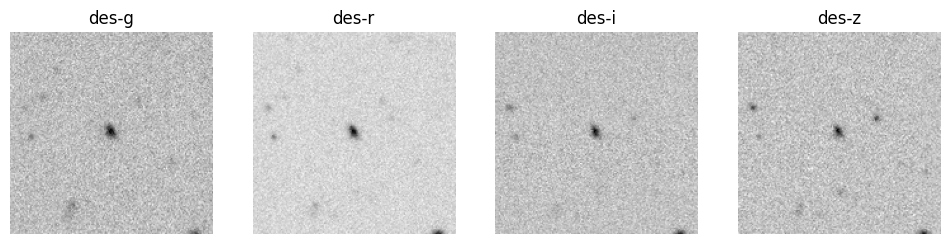

In [ ]:
figure(figsize=(12,5))
for i,b in enumerate(example['image']['band']):
  subplot(1,4,i+1)
  title(f'{b}')
  imshow(example['image']['flux'][i], cmap='gray_r')
  axis('off')

## Spectra Samples

In [ ]:
dset_sdss = load_dataset("MultimodalUniverse/sdss",
                       streaming=True,
                       split='train')
dset_sdss = dset_sdss.with_format("numpy")
dset_iterator = iter(dset_sdss)

In [ ]:
example = next(dset_iterator)

In [ ]:
# Let's inspect what is contained in an example
example.keys()

dict_keys(['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id'])

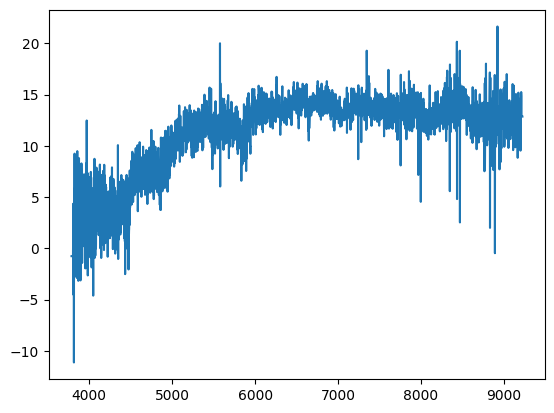

In [ ]:
# For plotting, we remove the padding values that are recognizable by the -1
m = example['spectrum']['lambda'] > 0

plot(example['spectrum']['lambda'][m],
     example['spectrum']['flux'][m])

## Time-Series sample

In [6]:
dset_plasticc = load_dataset("MultimodalUniverse/plasticc",
                       streaming=True,
                       split='train')
dset_plasticc = dset_plasticc.with_format("numpy")
dset_iterator = iter(dset_plasticc)

In [86]:
print(dset_iterator)

<generator object IterableDataset.__iter__ at 0x15aaf79a0>


In [55]:
example = next(dset_iterator)

In [84]:
arr = example.keys()
for k in arr:
    print(k, type(example[k]))

lc = example['lightcurve']
print(lc.keys())
for k, v in lc.items():
    print("\n", k)
    print(type(v))
    print(np.shape(v))
    print(v[:10] if hasattr(v, "__len__") else v)



lightcurve <class 'dict'>
hostgal_photoz <class 'numpy.float32'>
hostgal_specz <class 'numpy.float32'>
redshift <class 'numpy.float32'>
obj_type <class 'numpy.str_'>
object_id <class 'numpy.str_'>
dict_keys(['band', 'flux', 'flux_err', 'time'])

 band
<class 'numpy.ndarray'>
(912,)
['u' 'u' 'u' 'u' 'u' 'u' 'u' 'u' 'u' 'u']

 flux
<class 'numpy.ndarray'>
(912,)
[ 31.093987  32.507843 -16.298967 -12.777629  10.117995  -7.070136
   3.836947 -21.358648   5.856068   4.68775 ]

 flux_err
<class 'numpy.ndarray'>
(912,)
[ 7.687346  7.264877 13.154706  9.846336  9.668491  9.345154  7.768871
 10.116045  8.023105  9.716974]

 time
<class 'numpy.ndarray'>
(912,)
[59583.11  59586.16  59851.27  59874.246 59904.168 60176.387 60198.332
 60236.234 60291.086 60554.38 ]


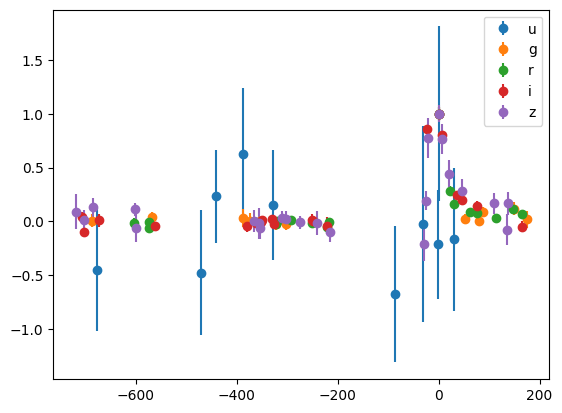

In [58]:
all_bands = ["u", "g", "r", "i", "z", "Y"]

for b in all_bands:
    mask = (band == b) & (time > 1000)

    if np.sum(mask) == 0:
        continue

    t = time[mask]
    f = flux[mask]
    e = flux_err[mask]

    t_peak = t[np.argmax(f)]
    t = t - t_peak

    max_f = np.max(f)
    if max_f <= 0:
        continue

    f = f / max_f
    e = e / max_f

    plt.errorbar(t, f, yerr=e, fmt="o", label=b)

handles, labels = plt.gca().get_legend_handles_labels()

unique = dict(zip(labels, handles))

plt.legend(unique.values(), unique.keys())
plt.show()

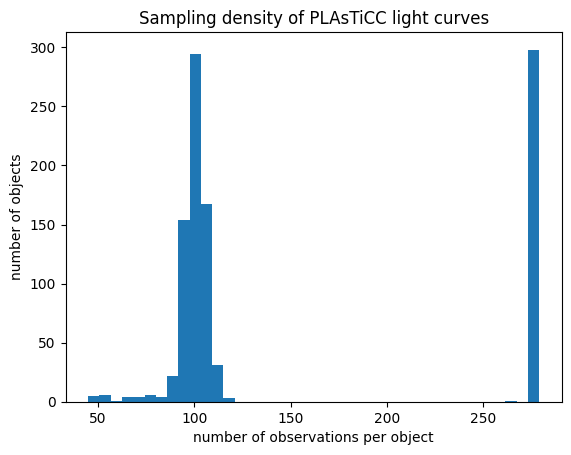

In [ ]:
counts = []

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(1000), dset_iterator):
    lc = example["lightcurve"]
    time = np.array(lc["time"])
    time = time[time > 0]
    counts.append(len(time))

plt.hist(counts, bins=40)
plt.xlabel("number of observations per object")
plt.ylabel("number of objects")   # how many objects have that number of observations
plt.title("Sampling density of PLAsTiCC light curves")
plt.show()

In [41]:
durations = []
dset_iterator = iter(dset_plasticc)
for i, example in zip(range(1000), dset_iterator):
    lc = example["lightcurve"]
    time = np.array(lc["time"])
    time = time[time > 10000]
    if len(time) > 0:
        duration = time.max() - time.min()
        durations.append(duration)

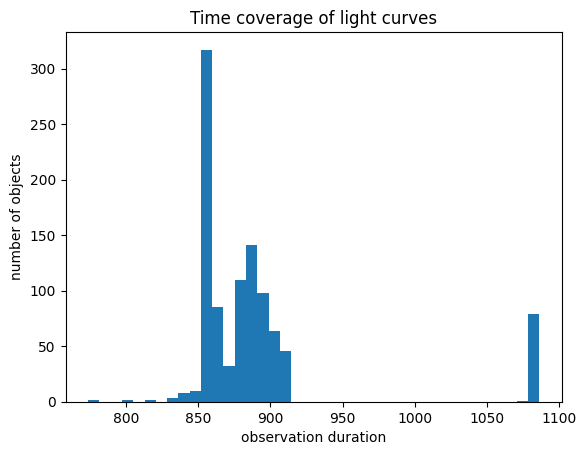

In [42]:
plt.hist(durations, bins=40)

plt.xlabel("observation duration")
plt.ylabel("number of objects")
plt.title("Time coverage of light curves")

plt.show()

In [67]:
lc = example["lightcurve"]

time = np.array(lc["time"])

print("min time:", time.min())
print("max time:", time.max())
print("time span:", time.max() - time.min())

min time: 0.0
max time: 60668.133
time span: 60668.133


In [45]:
# the number of observations in each band
from collections import Counter

band_counts = Counter()

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(1000), dset_iterator):

    lc = example["lightcurve"]
    band = np.array(lc["band"])

    for b in band:
        band_counts[b] += 1

print(band_counts)

Counter({'u': 197577, 'g': 197577, 'r': 197577, 'i': 197577, 'z': 197577, 'Y': 197577})


distribution of observations per band per object 

/var/folders/6n/52b69bhs4ts1df66shlc4gk40000gn/T/ipykernel_46613/1121265478.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=bands)


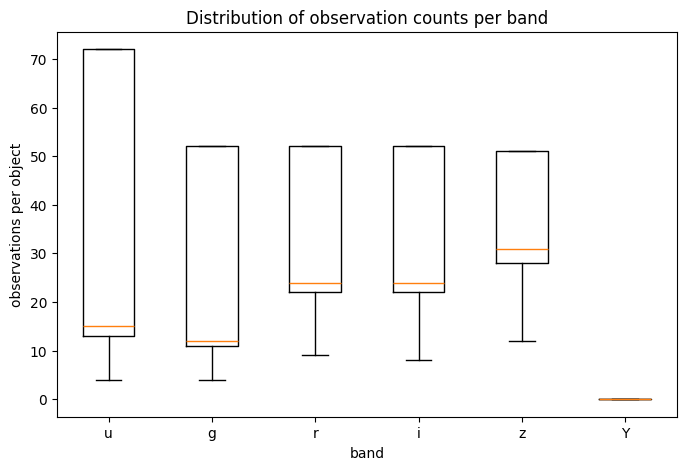

In [82]:
bands = ['u', 'g', 'r', 'i', 'z', 'Y']
band_obs = {b: [] for b in bands}

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(1000), dset_iterator):
    lc = example["lightcurve"]
    band = np.array(lc["band"])
    time = np.array(lc["time"])

    for b in bands:
        band_obs[b].append(np.sum((band == b) & (time > 0)))

data = [band_obs[b] for b in bands]

plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=bands)

plt.xlabel("band")
plt.ylabel("observations per object")
plt.title("Distribution of observation counts per band")
plt.show()

In [5]:
bands = ["u", "g", "r", "i", "z", "Y"]

rows = []

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(1000), dset_iterator):
    lc = example["lightcurve"]

    time = np.array(lc["time"])
    band = np.array(lc["band"])

    # optional: remove dummy/padding points
    valid = time > 0
    band_valid = band[valid]

    row = {
        "object_id": example["object_id"],
        "obj_type": example["obj_type"],
    }

    for b in bands:
        print(b, np.sum(band == b), np.sum((band == b) & (time > 0)))
        row[b] = np.sum(band_valid == b)

    row["total"] = sum(row[b] for b in bands)

    rows.append(row)

u 126 11
g 126 11
r 126 20
i 126 23
z 126 33
Y 126 0
u 126 11
g 126 11
r 126 17
i 126 22
z 126 34
Y 126 0
u 138 12
g 138 15
r 138 23
i 138 23
z 138 28
Y 138 0
u 138 12
g 138 15
r 138 23
i 138 23
z 138 28
Y 138 0
u 138 15
g 138 11
r 138 26
i 138 23
z 138 27
Y 138 0
u 140 14
g 140 12
r 140 24
i 140 23
z 140 30
Y 140 0
u 140 14
g 140 13
r 140 22
i 140 22
z 140 29
Y 140 0
u 140 13
g 140 9
r 140 23
i 140 22
z 140 30
Y 140 0
u 140 12
g 140 12
r 140 22
i 140 22
z 140 28
Y 140 0
u 140 16
g 140 12
r 140 25
i 140 23
z 140 28
Y 140 0
u 140 14
g 140 13
r 140 22
i 140 22
z 140 29
Y 140 0
u 132 14
g 132 9
r 132 23
i 132 21
z 132 24
Y 132 0
u 132 15
g 132 9
r 132 22
i 132 21
z 132 28
Y 132 0
u 132 15
g 132 9
r 132 24
i 132 24
z 132 26
Y 132 0
u 135 14
g 135 12
r 135 24
i 135 23
z 135 30
Y 135 0
u 135 15
g 135 9
r 135 26
i 135 20
z 135 30
Y 135 0
u 135 14
g 135 11
r 135 25
i 135 22
z 135 27
Y 135 0
u 135 14
g 135 8
r 135 26
i 135 21
z 135 31
Y 135 0
u 135 15
g 135 11
r 135 24
i 135 24
z 135 30
Y 135 0

In [11]:
# I want to know the number of objects in each class
class_counts = defaultdict(int)
dset_iterator = iter(dset_plasticc)
for i, example in zip(range(3000), dset_iterator):
    obj_type = str(example["obj_type"])
    class_counts[obj_type] += 1
# how to sort the class counts by the number of objects in each class
sorted_class_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))
print(sorted_class_counts)

{'SNIa': 874, 'SNII': 450, 'M-dwarf': 399, 'EB': 349, 'TDE': 201, 'SNIbc': 191, 'AGN': 136, 'RRL': 77, 'SNIa-91bg': 76, 'SLSN-I': 69, 'SNIax': 69, 'MicroLens-Single': 55, 'KN': 44, 'Mira': 10}


In [ ]:
# the flux values at time = 0 are padding entries, proof:
flux = np.array(lc["flux"])
flux_err = np.array(lc["flux_err"])
mask = time == 0
print(flux[mask][:10])
print(flux_err[mask][:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [6]:
obs_counts_df = pd.DataFrame(rows)

obs_counts_df.head(50)

,object_id,obj_type,u,g,r,i,z,Y,total
0,21846282,SNIa,11,11,20,23,33,0,98
1,114421739,AGN,11,11,17,22,34,0,95
2,30652072,SNII,12,15,23,23,28,0,101
3,107732897,TDE,12,15,23,23,28,0,101
4,121186562,AGN,15,11,26,23,27,0,102
5,10905347,SNII,14,12,24,23,30,0,103
6,16775731,SNIa,14,13,22,22,29,0,100
7,31971611,SNII,13,9,23,22,30,0,97
8,50875482,SNIbc,12,12,22,22,28,0,96
9,52437992,AGN,16,12,25,23,28,0,104


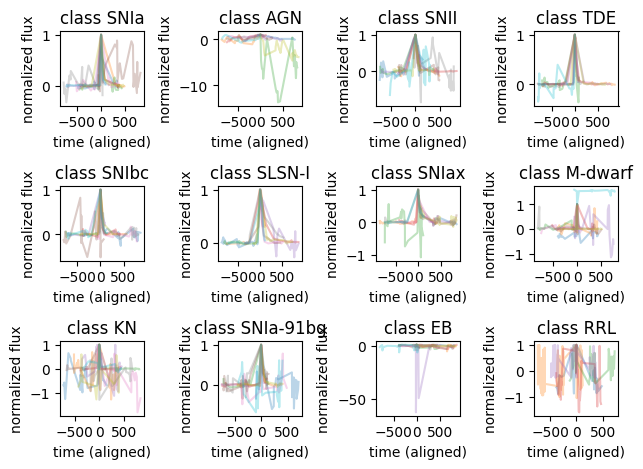

In [52]:
dset_iterator = iter(dset_plasticc)
curves = {}

for i, example in zip(range(500), dset_iterator):
    lc = example["lightcurve"]
    time = np.array(lc["time"])
    flux = np.array(lc["flux"])
    band = np.array(lc["band"])

    mask = (band == "r") & (time > 10000)

    t = time[mask]
    f = flux[mask]

    if len(t) < 5:
        continue
    t_peak = t[np.argmax(f)]
    t = t - t_peak
    f = f / np.max(f)

    obj_type = example["obj_type"]
    curves.setdefault(obj_type, []).append((t, f))

# plot the first 10 curves of each class
i = 0
for obj_type, data in curves.items():
    i += 1
    plt.subplot(3, 4, i)
    for t, f in data[:10]:
        plt.plot(t, f, alpha=0.3)

    plt.title(f"class {obj_type}")
    plt.xlabel("time (aligned)")
    plt.ylabel("normalized flux")
plt.tight_layout()
plt.show()

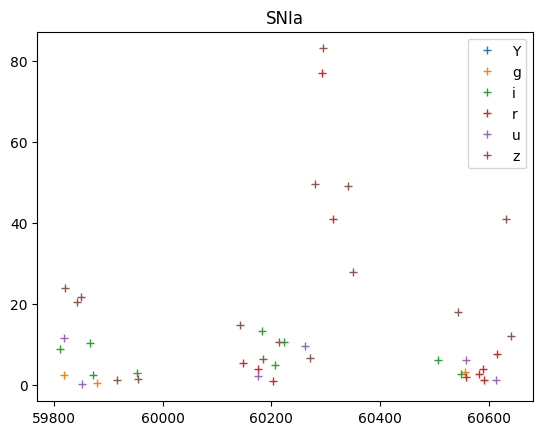

In [8]:
import numpy as np
import matplotlib.pyplot as plt

for b in np.unique(example['lightcurve']['band']):
  m = (example['lightcurve']['flux'] > 0) & (example['lightcurve']['band'] == b)
  plt.plot(example['lightcurve']['time'][m],
      example['lightcurve']['flux'][m],'+', label=b)
  plt.title(example['obj_type'])
plt.legend();

In [9]:
target_classes = ["AGN", "SNIax"]
time_bins = np.linspace(-300, 500, 50)
bin_centers = 0.5 * (time_bins[:-1] + time_bins[1:])

class_band_data = {
    c: defaultdict(list) for c in target_classes
}

dset_iterator = iter(dset_plasticc)

for i, example in zip(range(3000), dset_iterator):
    obj_type = str(example["obj_type"])
    if obj_type not in target_classes:
        continue
    lc = example["lightcurve"]
    time = np.array(lc["time"])
    flux = np.array(lc["flux"])
    band = np.array(lc["band"])
    mask = time > 10000
    time = time[mask]
    flux = flux[mask]
    band = band[mask]

    if len(time) < 10:
        continue
    
    # align by global peak across all bands
    max_flux = np.max(flux)
    if max_flux <= 0:
        continue
    t_peak = time[np.argmax(flux)]
    time_aligned = time - t_peak
    flux_norm = flux / max_flux
    
    for b in np.unique(band):
        m = band == b
        t_b = time_aligned[m]
        f_b = flux_norm[m]

        # bin in time
        digitized = np.digitize(t_b, time_bins)

        for k in range(1, len(time_bins)):
            vals = f_b[digitized == k]
            if len(vals) > 0:
                class_band_data[obj_type][b].append(
                    (bin_centers[k-1], np.mean(vals))
                )

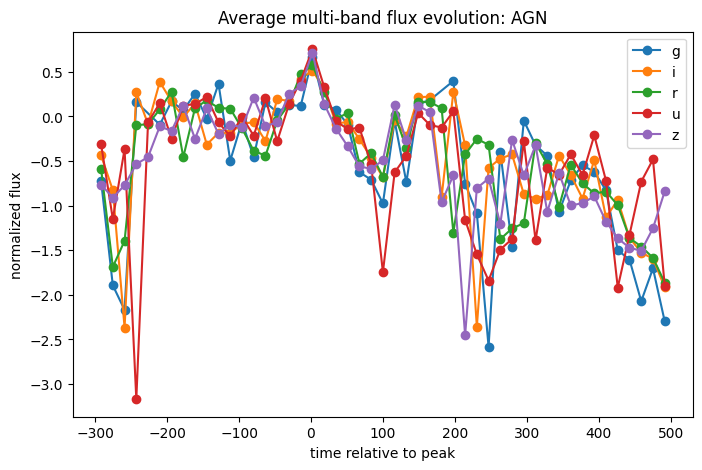

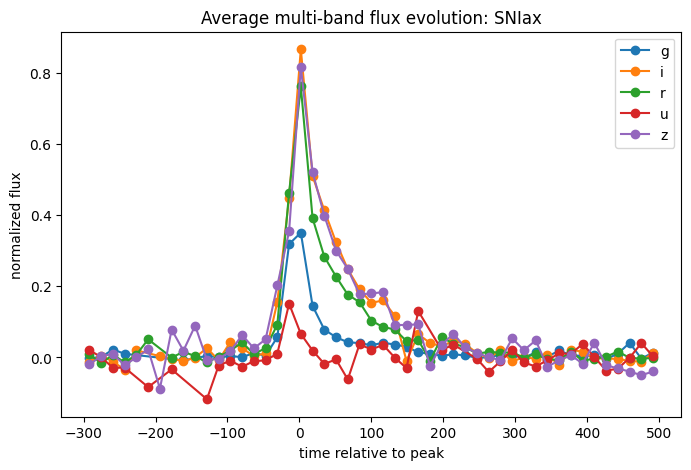

In [10]:
for c in target_classes:
    plt.figure(figsize=(8, 5))

    for b, pairs in class_band_data[c].items():
        pairs = np.array(pairs)

        if len(pairs) == 0:
            continue

        mean_curve = []
        valid_centers = []

        for center in bin_centers:
            vals = pairs[pairs[:, 0] == center, 1]
            if len(vals) >= 3:
                valid_centers.append(center)
                mean_curve.append(np.mean(vals))

        plt.plot(valid_centers, mean_curve, marker="o", label=str(b))

    plt.title(f"Average multi-band flux evolution: {c}")
    plt.xlabel("time relative to peak")
    plt.ylabel("normalized flux")
    plt.legend()
    plt.show()

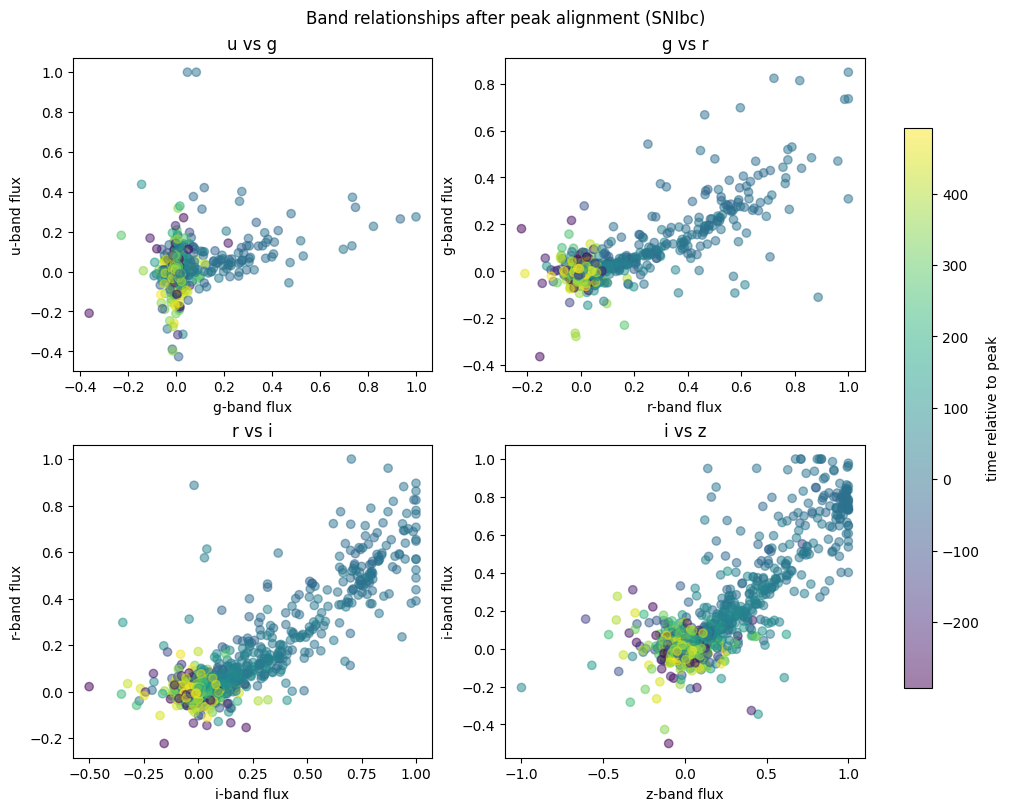

In [22]:
target_class = "SNIbc"
sc = None

bands = ["u","g","r","i","z"]
band_pairs = [("u","g"), ("g","r"), ("r","i"), ("i","z")]

#fig, axes = plt.subplots(2,2, figsize=(10,8))
fig, axes = plt.subplots(2,2, figsize=(10,8), constrained_layout=True)
axes = axes.flatten()

for ax, (b1,b2) in zip(axes, band_pairs):

    f1_all = []
    f2_all = []
    time_all = []

    dset_iterator = iter(dset_plasticc)

    for i, example in zip(range(3000), dset_iterator):

        if str(example["obj_type"]) != target_class:
            continue

        lc = example["lightcurve"]

        time = np.array(lc["time"])
        flux = np.array(lc["flux"])
        band = np.array(lc["band"])

        valid = time > 0
        time = time[valid]
        flux = flux[valid]
        band = band[valid]

        if len(time) == 0:
            continue

        t_peak = time[np.argmax(flux)]
        time_aligned = time - t_peak

        max_flux = np.max(flux)
        if max_flux <= 0:
            continue

        flux_norm = flux / max_flux

        digitized = np.digitize(time_aligned, time_bins)

        for k in range(1,len(time_bins)):

            in_bin = digitized == k

            vals1 = flux_norm[in_bin & (band == b1)]
            vals2 = flux_norm[in_bin & (band == b2)]

            if len(vals1) > 0 and len(vals2) > 0:
                f1_all.append(np.mean(vals1))
                f2_all.append(np.mean(vals2))
                time_all.append(bin_centers[k-1])

    if len(f1_all) > 0:
        sc = ax.scatter(f2_all, f1_all, c=time_all, cmap="viridis", alpha=0.5)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")

    ax.set_xlabel(f"{b2}-band flux")
    ax.set_ylabel(f"{b1}-band flux")
    ax.set_title(f"{b1} vs {b2}")

fig.suptitle(f"Band relationships after peak alignment ({target_class})")
if sc is not None:
    fig.colorbar(sc, ax=axes, label="time relative to peak", shrink=0.8)
plt.show()

## Cross-Matching Across Modalities

While each parent sample is based on a single modality, users can easily create datasets across modalities by using the provided utilities.

This requires downloading the datasets to cross-match locally on local storage, and installing our utility library.


In the example below, we download a small fraction of 2 parent samples for demonstration purposes. For real applications, please see the project README to see how to download entire datasets.


#### - Installing the utility library

In [ ]:
!pip install git+https://github.com/MultimodalUniverse/MultimodalUniverse.git --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


#### - Downloading a small fraction of the data

The lines below download specifically a matching small healpix region of both the HSC imaging sample, and the SDSS spectroscospic dataset.

In [ ]:
# Downloading a small fraction of the data for demonstration purposes
!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/hsc/pdr3_dud_22.5/healpix=1175/
!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/hsc/hsc.py
!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/sdss/sdss/healpix=1175/
!wget -r -np -nH --cut-dirs=1 -R "index.html*" -q https://users.flatironinstitute.org/~polymathic/data/MultimodalUniverse/v1/sdss/sdss.py

#### - Building cross-matched dataset

In [ ]:
from datasets import load_dataset_builder
from mmu.utils import cross_match_datasets

In [ ]:
# Load the dataset descriptions from local copy of the data
sdss = load_dataset_builder("data/MultimodalUniverse/v1/sdss", trust_remote_code=True)
hsc = load_dataset_builder("data/MultimodalUniverse/v1/hsc", trust_remote_code=True)

In [ ]:
# Use the cross matching utility to return a new HF dataset, the intersection
# of the parent samples.
dset = cross_match_datasets(sdss, # Left dataset
                            hsc,  # Right dataset
                            matching_radius=1.0, # Distance in arcsec
                            )

Initial number of matches:  25
Number of matches lost at healpix region borders:  0
Final size of cross-matched catalog:  25


In [ ]:
# The resulting dataset contains columns from both parent samples
dset

Dataset({
    features: ['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id', 'image', 'a_g', 'a_r', 'a_i', 'a_z', 'a_y', 'g_extendedness_value', 'r_extendedness_value', 'i_extendedness_value', 'z_extendedness_value', 'y_extendedness_value', 'g_cmodel_mag', 'g_cmodel_magerr', 'r_cmodel_mag', 'r_cmodel_magerr', 'i_cmodel_mag', 'i_cmodel_magerr', 'z_cmodel_mag', 'z_cmodel_magerr', 'y_cmodel_mag', 'y_cmodel_magerr', 'g_sdssshape_psf_shape11', 'g_sdssshape_psf_shape22', 'g_sdssshape_psf_shape12', 'r_sdssshape_psf_shape11', 'r_sdssshape_psf_shape22', 'r_sdsss

In [ ]:
# Formating HF Dataset to JAX
dset = dset.with_format('jax')

We now have a dataset that contains both images and spectra of the same object.

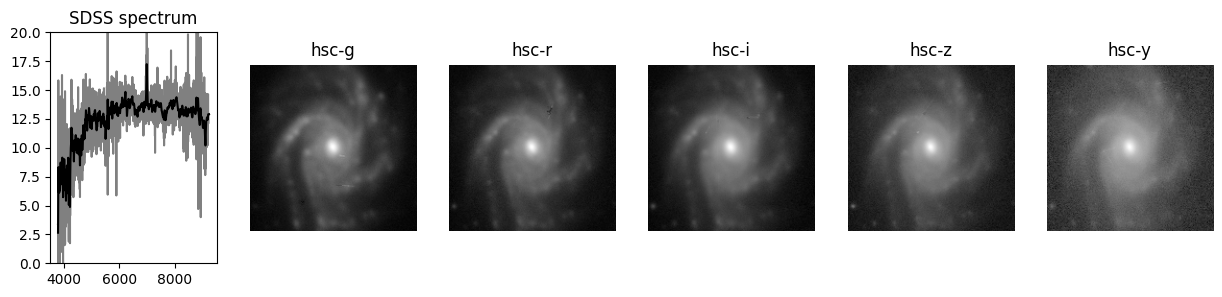

In [ ]:
example = dset[3]

from scipy.ndimage import gaussian_filter1d
figure(figsize=[15,3])
subplot(1,6,1)
ylim(0,20)
m = example['spectrum']['lambda'] > 0
plot(example['spectrum']['lambda'][m], example['spectrum']['flux'][m], color='gray')
plot(example['spectrum']['lambda'][m], gaussian_filter1d(example['spectrum']['flux'], sigma=5)[m], color='k')

title('SDSS spectrum')
for i in range (5):
    subplot(1,6,i+2)
    imshow(log10(example['image']['flux'][i] + 2.), cmap='gray')
    title(example['image']['band'][i])
    axis('off')